In [ ]:
# ─────────────────────────────────────────────
# PART 1: Install & Imports
# ─────────────────────────────────────────────
!pip install open3d plotly huggingface_hub numpy scipy wandb -q
!pip install torch scikit-learn -q

import open3d as o3d
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import wandb
import os
import zipfile
from sklearn.decomposition import PCA
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.4 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# PART 2: Download & Extract Dataset
# ─────────────────────────────────────────────
zip_path = hf_hub_download(
    repo_id="BGLab/AgriField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="./data"
)

extract_dir = "./data/RawPCD_10k"
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

ply_files = sorted([
    os.path.join(root, f)
    for root, _, files in os.walk(extract_dir)
    for f in files if f.endswith('.ply')
])
print(f"Total plants found: {len(ply_files)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Total plants found: 1045


In [ ]:
# ─────────────────────────────────────────────
# PART 3: Dataset + Fixed 500 / Rest Split
# ─────────────────────────────────────────────
NUM_POINTS = 1024
TRAIN_SIZE = 500

def preprocess(ply_path, num_points=NUM_POINTS):
    """
    Load .ply → subsample → centre → normalise to unit sphere.
    Returns float32 array [num_points, 3].
    """
    pcd = o3d.io.read_point_cloud(ply_path)
    pts = np.asarray(pcd.points, dtype=np.float32)
    if pts.shape[0] == 0:
        return None
    N   = pts.shape[0]
    idx = (np.random.choice(N, num_points, replace=False)
           if N >= num_points
           else np.random.choice(N, num_points, replace=True))
    pts  = pts[idx]
    pts -= pts.mean(axis=0)
    pts /= (np.linalg.norm(pts, axis=1).max() + 1e-8)
    return pts


class MaizeDataset(Dataset):
    def __init__(self, ply_files):
        self.samples = []
        self.paths   = []
        print(f"Loading {len(ply_files)} files …")
        for i, path in enumerate(ply_files):
            try:
                pts = preprocess(path)
                if pts is not None:
                    self.samples.append(
                        torch.tensor(pts))
                    self.paths.append(path)
            except Exception as e:
                print(f"  [skip] "
                      f"{os.path.basename(path)}: {e}")
            if (i+1) % 20 == 0:
                print(f"  {i+1}/{len(ply_files)} — "
                      f"{len(self.samples)} valid")
        print(f"Dataset ready: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Return point cloud + index for tracking
        return self.samples[idx], idx


# ── Build full dataset ────────────────────────────────────────────────
full_dataset  = MaizeDataset(ply_files)
total         = len(full_dataset)

# Fixed random split — reproducible with SEED
all_indices   = np.random.permutation(total)
train_indices = all_indices[:TRAIN_SIZE].tolist()
test_indices  = all_indices[TRAIN_SIZE:].tolist()

train_dataset = Subset(full_dataset, train_indices)
test_dataset  = Subset(full_dataset, test_indices)

train_loader  = DataLoader(
    train_dataset, batch_size=8,
    shuffle=True,  drop_last=True)
test_loader   = DataLoader(
    test_dataset,  batch_size=8,
    shuffle=False, drop_last=False)

print(f"\nTrain : {len(train_dataset)}")
print(f"Test  : {len(test_dataset)} (unseen during training)")

Loading 1045 files …
  20/1045 — 20 valid
  40/1045 — 40 valid
  60/1045 — 60 valid
  80/1045 — 80 valid
  100/1045 — 100 valid
  120/1045 — 120 valid
  140/1045 — 140 valid
  160/1045 — 160 valid
  180/1045 — 180 valid
  200/1045 — 200 valid
  220/1045 — 220 valid
  240/1045 — 240 valid
  260/1045 — 260 valid
  280/1045 — 280 valid
  300/1045 — 300 valid
  320/1045 — 320 valid
  340/1045 — 340 valid
  360/1045 — 360 valid
  380/1045 — 380 valid
  400/1045 — 400 valid
  420/1045 — 420 valid
  440/1045 — 440 valid
  460/1045 — 460 valid
  480/1045 — 480 valid
  500/1045 — 500 valid
  520/1045 — 520 valid
  540/1045 — 540 valid
  560/1045 — 560 valid
  580/1045 — 580 valid
  600/1045 — 600 valid
  620/1045 — 620 valid
  640/1045 — 640 valid
  660/1045 — 660 valid
  680/1045 — 680 valid
  700/1045 — 700 valid
  720/1045 — 720 valid
  740/1045 — 740 valid
  760/1045 — 760 valid
  780/1045 — 780 valid
  800/1045 — 800 valid
  820/1045 — 820 valid
  840/1045 — 840 valid
  860/1045 — 860 vali

In [ ]:
# ─────────────────────────────────────────────
# PART 4: DGCNN Autoencoder
#
# IMPROVEMENTS (from reference notebook):
#   - k=16 (was 10): wider neighbourhood → more context
#   - Decoder: removed BatchNorm (destabilises point generation)
#   - Decoder: uses ReLU (not LeakyReLU) for cleaner output
#   - Kept 4-block multi-scale encoder (better than 3-block)
# ─────────────────────────────────────────────

def knn(x, k):
    """
    Find k nearest neighbours for each point.
    x   : [B, C, N]
    Returns idx : [B, N, k]
    """
    inner             = -2 * torch.matmul(
                              x.transpose(2,1), x)
    xx                = torch.sum(
                              x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2,1)
    return pairwise_distance.topk(k=k, dim=-1)[1]


def get_graph_feature(x, k=20):
    """
    Build edge features for each point from its
    k nearest neighbours.
    x      : [B, C, N]
    Returns: [B, 2C, N, k]
    """
    B, C, N  = x.size()
    idx      = knn(x, k)
    idx_base = torch.arange(
                   0, B, device=x.device
               ).view(-1,1,1) * N
    idx      = (idx + idx_base).view(-1)

    x_t     = x.transpose(2,1).contiguous()
    feature = x_t.view(B*N, -1)[idx, :]
    feature = feature.view(B, N, k, C)
    x_t     = x_t.view(
                   B, N, 1, C).repeat(1,1,k,1)
    feature = torch.cat(
                   (feature - x_t, x_t), dim=3)
    return feature.permute(0,3,1,2)


class DGCNN_Encoder(nn.Module):
    """
    4 EdgeConv blocks with multi-scale feature concat.

    Block 1 : 3×2=6   → 64
    Block 2 : 64×2=128 → 64
    Block 3 : 64×2=128 → 128
    Block 4 : 128×2=256 → 256
    Concat  : 64+64+128+256 = 512
    FC      : 512 → latent_dim
    """
    def __init__(self, k=16, latent_dim=256):
        super().__init__()
        self.k = k

        self.conv1 = nn.Sequential(
            nn.Conv2d(6,   64,  kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2))

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 64,  kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2))

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2))

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2))

        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, latent_dim)
        )

    def forward(self, x):
        """x : [B, 3, N]"""
        B  = x.size(0)
        k  = self.k

        x0 = self.conv1(
                 get_graph_feature(x,  k)).max(-1)[0]
        x1 = self.conv2(
                 get_graph_feature(x0, k)).max(-1)[0]
        x2 = self.conv3(
                 get_graph_feature(x1, k)).max(-1)[0]
        x3 = self.conv4(
                 get_graph_feature(x2, k)).max(-1)[0]

        xg = torch.cat((x0,x1,x2,x3), dim=1)
        xg = F.adaptive_max_pool1d(
                 xg, 1).view(B, -1)
        return self.fc(xg)


class DGCNN_Decoder(nn.Module):
    """
    MLP decoder: latent → point cloud [B, N, 3]

    IMPROVEMENT: No BatchNorm in decoder.
    BatchNorm normalises across the batch dimension which
    can destabilise point cloud generation — each plant has
    a unique shape, so forcing batch statistics hurts diversity.
    Uses plain ReLU for cleaner gradient flow.
    """
    def __init__(self, latent_dim=256,
                 num_points=NUM_POINTS):
        super().__init__()
        self.num_points = num_points
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512,  1024),
            nn.ReLU(),
            nn.Linear(1024, num_points * 3)
        )

    def forward(self, z):
        return self.net(z).view(
                   -1, self.num_points, 3)


class DGCNN_Autoencoder(nn.Module):
    def __init__(self, k=16, latent_dim=256,
                 num_points=NUM_POINTS):
        super().__init__()
        self.encoder = DGCNN_Encoder(
                           k=k, latent_dim=latent_dim)
        self.decoder = DGCNN_Decoder(
                           latent_dim=latent_dim,
                           num_points=num_points)

    def forward(self, x):
        """
        x : [B, N, 3]
        Returns: recon [B, N, 3], latent [B, latent_dim]
        """
        z     = self.encoder(x.transpose(2,1))
        recon = self.decoder(z)
        return recon, z


def chamfer_distance(pred, target):
    """
    pred, target : [B, N, 3]
    Order-invariant reconstruction loss.
    """
    d1 = (pred.unsqueeze(2) -
          target.unsqueeze(1)).pow(2).sum(-1)
    d2 = (target.unsqueeze(2) -
          pred.unsqueeze(1)).pow(2).sum(-1)
    return d1.min(2)[0].mean() + d2.min(2)[0].mean()


In [ ]:
# ─────────────────────────────────────────────
# PART 5: Checkpoint Utilities
# ─────────────────────────────────────────────
CKPT_DIR = "./checkpoints_dgcnn"
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, scheduler,
                    epoch, loss, tag="latest"):
    path = os.path.join(CKPT_DIR, f"dgcnn_{tag}.pt")
    ckpt = {
        "epoch"       : epoch,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "loss"        : loss,
    }
    if scheduler is not None:
        ckpt["sched_state"] = scheduler.state_dict()
    torch.save(ckpt, path)
    return path


def load_checkpoint(path, model,
                    optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer and "optim_state" in ckpt:
        optimizer.load_state_dict(ckpt["optim_state"])
    if scheduler and "sched_state" in ckpt:
        scheduler.load_state_dict(ckpt["sched_state"])
    print(f"  Loaded — epoch {ckpt['epoch']} "
          f"| loss {ckpt['loss']:.6f}")
    return ckpt


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_log,█▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,223
lr,0.0001
train_loss,0.00183
train_loss_log,-2.73646


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch   50 | Loss 0.005592 | ckpt saved
Epoch  100 | Loss 0.003769 | ckpt saved
Epoch  150 | Loss 0.002663 | ckpt saved
Epoch  200 | Loss 0.002017 | ckpt saved
Epoch  250 | Loss 0.001540 | ckpt saved
Epoch  300 | Loss 0.001252 | ckpt saved
Epoch  350 | Loss 0.001035 | ckpt saved
Epoch  400 | Loss 0.000916 | ckpt saved
Epoch  450 | Loss 0.000771 | ckpt saved
Epoch  500 | Loss 0.000703 | ckpt saved
Epoch  550 | Loss 0.000623 | ckpt saved
Epoch  600 | Loss 0.000580 | ckpt saved
Epoch  650 | Loss 0.000548 | ckpt saved
Epoch  700 | Loss 0.000516 | ckpt saved
Epoch  750 | Loss 0.000463 | ckpt saved
Epoch  800 | Loss 0.000451 | ckpt saved
Epoch  850 | Loss 0.000434 | ckpt saved
Epoch  900 | Loss 0.000414 | ckpt saved
Epoch  950 | Loss 0.000404 | ckpt saved
Epoch 1000 | Loss 0.000385 | ckpt saved


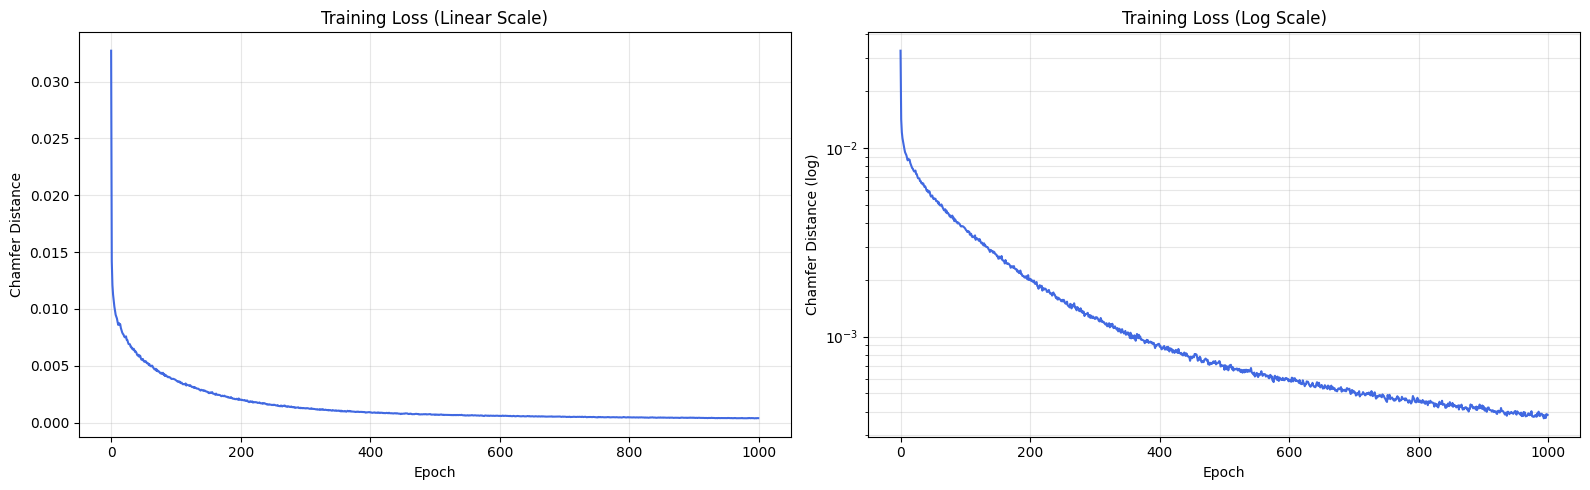

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_log,█▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch,1000
lr,0.0001
train_loss,0.00038
train_loss_log,-3.41506


Training done. Best loss: 0.000369


In [ ]:
# ─────────────────────────────────────────────
# PART 6: Training — 500 samples, 500 epochs
#
# IMPROVEMENTS:
#   - k=16 (wider neighbourhood)
#   - lr=1e-4 (slower, more precise — key change)
#   - No weight_decay (was interfering with fine detail)
#   - No LR scheduler (constant 1e-4 is stable enough)
#   - No gradient clipping (lr=1e-4 is inherently safe)
#   - Log-scale loss in both W&B and Colab
# ─────────────────────────────────────────────
import math
import matplotlib.pyplot as plt

CONFIG = dict(
    epochs           = 1000,
    batch_size       = 8,
    lr               = 1e-4,
    k                = 16,
    latent_dim       = 256,
    num_points       = NUM_POINTS,
    train_size       = TRAIN_SIZE,
    checkpoint_every = 50,
)

wandb.init(
    project = "maize-dgcnn2",
    config  = CONFIG,
    name    = "dgcnn-improved-k16-lr1e4"
)

model     = DGCNN_Autoencoder(
                k          = CONFIG["k"],
                latent_dim = CONFIG["latent_dim"],
                num_points = CONFIG["num_points"]
            ).to(device)

# No weight_decay — cleaner gradient flow for point generation
optimizer = torch.optim.Adam(
                model.parameters(),
                lr=CONFIG["lr"])

# No scheduler — constant lr=1e-4 converges smoothly

wandb.watch(model, log="all", log_freq=20)

best_loss    = float("inf")
train_losses = []

for epoch in range(1, CONFIG["epochs"] + 1):

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for batch, _ in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss     = chamfer_distance(recon, batch)
        loss.backward()
        # No gradient clipping — lr=1e-4 is safe enough
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    # ── W&B logging (log scale) ────────────────────────────────────
    log_loss = math.log10(epoch_loss) if epoch_loss > 0 else -10
    wandb.log({
        "epoch"          : epoch,
        "train_loss"     : epoch_loss,
        "train_loss_log" : log_loss,
        "lr"             : CONFIG["lr"],
    })

    # Log 3D point clouds every 50 epochs
    if epoch % 50 == 0:
        model.eval()
        sample = next(iter(train_loader))[0][:1].to(device)
        with torch.no_grad():
            s_recon, _ = model(sample)
        o = sample[0].cpu().numpy()
        r = s_recon[0].cpu().numpy()
        wandb.log({
            f"train_original_ep{epoch}": wandb.Object3D(
                np.hstack([o,
                    np.tile([0,120,255],(len(o),1))])),
            f"train_recon_ep{epoch}"   : wandb.Object3D(
                np.hstack([r,
                    np.tile([255,80,0], (len(r),1))])),
        })
        model.train()

    # ── Periodic checkpoint ────────────────────────────────────────
    if epoch % CONFIG["checkpoint_every"] == 0:
        path = save_checkpoint(
            model, optimizer, None,
            epoch, epoch_loss, tag="latest")
        wandb.save(path)
        print(f"Epoch {epoch:4d} | "
              f"Loss {epoch_loss:.6f} | ckpt saved")

    # ── Best model checkpoint ──────────────────────────────────────
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        path = save_checkpoint(
            model, optimizer, None,
            epoch, epoch_loss, tag="best")
        wandb.save(path)

# ── Loss curves — LOG SCALE in both Colab and W&B ─────────────────────

# --- Colab: matplotlib log-scale plot ---
fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(train_losses, color='royalblue', linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Chamfer Distance")
ax1.set_title("Training Loss (Linear Scale)")
ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color='royalblue', linewidth=1.5)
ax2.set_yscale('log')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Chamfer Distance (log)")
ax2.set_title("Training Loss (Log Scale)")
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# --- W&B: Plotly log-scale plot ---
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(
    y=train_losses,
    mode='lines',
    line=dict(color='royalblue', width=2),
    name='Train Loss'
))
fig_loss.update_layout(
    title       = "DGCNN — Training Loss (Log Scale)",
    xaxis_title = "Epoch",
    yaxis_title = "Chamfer Distance",
    yaxis_type  = "log",
    template    = "plotly_dark"
)
fig_loss.show()
wandb.log({"loss_curve_log": wandb.Plotly(fig_loss)})

# Also log a linear-scale version to W&B
fig_loss_lin = go.Figure()
fig_loss_lin.add_trace(go.Scatter(
    y=train_losses,
    mode='lines',
    line=dict(color='royalblue', width=2),
    name='Train Loss'
))
fig_loss_lin.update_layout(
    title       = "DGCNN — Training Loss (Linear Scale)",
    xaxis_title = "Epoch",
    yaxis_title = "Chamfer Distance",
    template    = "plotly_dark"
)
wandb.log({"loss_curve_linear": wandb.Plotly(fig_loss_lin)})

wandb.finish()
print(f"Training done. Best loss: {best_loss:.6f}")


In [ ]:
# ─────────────────────────────────────────────
# PART 7: Evaluate & Visualize — TRAIN SET
# ─────────────────────────────────────────────
wandb.init(
    project = "maize-dgcnn",
    name    = "dgcnn-viz-train",
    resume  = "allow"
)

model = DGCNN_Autoencoder(
            k          = CONFIG["k"],
            latent_dim = CONFIG["latent_dim"],
            num_points = CONFIG["num_points"]
        ).to(device)
load_checkpoint(
    os.path.join(CKPT_DIR, "dgcnn_best.pt"), model)
model.eval()

# ── Collect all train reconstructions ────────────────────────────────
train_orig_list  = []
train_recon_list = []

with torch.no_grad():
    for batch, _ in train_loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        train_orig_list.append(batch.cpu().numpy())
        train_recon_list.append(recon.cpu().numpy())

train_orig  = np.concatenate(train_orig_list,  axis=0)
train_recon = np.concatenate(train_recon_list, axis=0)

# ── Per-sample Chamfer scores ─────────────────────────────────────────
train_cd = np.array([
    chamfer_distance(
        torch.tensor(train_orig[i]).unsqueeze(0),
        torch.tensor(train_recon[i]).unsqueeze(0)
    ).item()
    for i in range(len(train_orig))
])
print(f"Train — Mean CD : {train_cd.mean():.6f} "
      f"| Std : {train_cd.std():.6f}")

# ── Plot best 4 + worst 4 ─────────────────────────────────────────────
show_idx = (list(np.argsort(train_cd)[:4]) +
            list(np.argsort(train_cd)[-4:]))
labels   = ([f"Best {i+1}"  for i in range(4)] +
            [f"Worst {i+1}" for i in range(4)])

fig_train = make_subplots(
    rows=8, cols=2,
    specs=[[{"type":"scatter3d"},
            {"type":"scatter3d"}]] * 8,
    subplot_titles=[
        t for lbl, idx in zip(labels, show_idx)
        for t in (
            f"{lbl} — Original "
            f"(CD={train_cd[idx]:.5f})",
            f"{lbl} — Reconstructed"
        )
    ],
    vertical_spacing=0.02
)

for row, idx in enumerate(show_idx, start=1):
    o = train_orig[idx]
    r = train_recon[idx]
    fig_train.add_trace(go.Scatter3d(
        x=o[:,0], y=o[:,1], z=o[:,2],
        mode='markers',
        marker=dict(size=1.5, color=o[:,2],
                    colorscale='Viridis',
                    showscale=False),
        showlegend=False
    ), row=row, col=1)
    fig_train.add_trace(go.Scatter3d(
        x=r[:,0], y=r[:,1], z=r[:,2],
        mode='markers',
        marker=dict(size=1.5, color=r[:,2],
                    colorscale='Plasma',
                    showscale=False),
        showlegend=False
    ), row=row, col=2)

fig_train.update_layout(
    title    = "DGCNN Train Set — Best 4 & Worst 4",
    template = "plotly_dark",
    height   = 3600,
    margin   = dict(l=10, r=10, t=60, b=10)
)
fig_train.show()
wandb.log({"train_reconstructions":
               wandb.Plotly(fig_train)})

# ── Train CD histogram ────────────────────────────────────────────────
fig_hist_train = px.histogram(
    x=train_cd, nbins=40,
    title="Train Set — Chamfer Distance Distribution",
    labels={"x":"Chamfer Distance","y":"Count"},
    template="plotly_dark",
    color_discrete_sequence=["#636EFA"]
)
fig_hist_train.show()
wandb.log({"train_cd_hist":
               wandb.Plotly(fig_hist_train)})

wandb.finish()

  Loaded — epoch 994 | loss 0.000369
Train — Mean CD : 0.000500 | Std : 0.000220


In [ ]:
# ─────────────────────────────────────────────
# PART 8: Evaluate & Visualize — TEST SET
# ─────────────────────────────────────────────
wandb.init(
    project = "maize-dgcnn",
    name    = "dgcnn-viz-test",
    resume  = "allow"
)

model = DGCNN_Autoencoder(
            k          = CONFIG["k"],
            latent_dim = CONFIG["latent_dim"],
            num_points = CONFIG["num_points"]
        ).to(device)
load_checkpoint(
    os.path.join(CKPT_DIR, "dgcnn_best.pt"), model)
model.eval()

# ── Collect all test reconstructions ──────────────────────────────────
test_orig_list  = []
test_recon_list = []

with torch.no_grad():
    for batch, _ in test_loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        test_orig_list.append(batch.cpu().numpy())
        test_recon_list.append(recon.cpu().numpy())

test_orig  = np.concatenate(test_orig_list,  axis=0)
test_recon = np.concatenate(test_recon_list, axis=0)

# ── Per-sample Chamfer scores ─────────────────────────────────────────
test_cd = np.array([
    chamfer_distance(
        torch.tensor(test_orig[i]).unsqueeze(0),
        torch.tensor(test_recon[i]).unsqueeze(0)
    ).item()
    for i in range(len(test_orig))
])
print(f"Test  — Mean CD : {test_cd.mean():.6f} "
      f"| Std : {test_cd.std():.6f}")

# ── Plot best 4 + worst 4 ─────────────────────────────────────────────
show_idx = (list(np.argsort(test_cd)[:4]) +
            list(np.argsort(test_cd)[-4:]))
labels   = ([f"Best {i+1}"  for i in range(4)] +
            [f"Worst {i+1}" for i in range(4)])

fig_test = make_subplots(
    rows=8, cols=2,
    specs=[[{"type":"scatter3d"},
            {"type":"scatter3d"}]] * 8,
    subplot_titles=[
        t for lbl, idx in zip(labels, show_idx)
        for t in (
            f"{lbl} — Original "
            f"(CD={test_cd[idx]:.5f})",
            f"{lbl} — Reconstructed"
        )
    ],
    vertical_spacing=0.02
)

for row, idx in enumerate(show_idx, start=1):
    o = test_orig[idx]
    r = test_recon[idx]
    fig_test.add_trace(go.Scatter3d(
        x=o[:,0], y=o[:,1], z=o[:,2],
        mode='markers',
        marker=dict(size=1.5, color=o[:,2],
                    colorscale='Viridis',
                    showscale=False),
        showlegend=False
    ), row=row, col=1)
    fig_test.add_trace(go.Scatter3d(
        x=r[:,0], y=r[:,1], z=r[:,2],
        mode='markers',
        marker=dict(size=1.5, color=r[:,2],
                    colorscale='Plasma',
                    showscale=False),
        showlegend=False
    ), row=row, col=2)

fig_test.update_layout(
    title    = "DGCNN Test Set — Best 4 & Worst 4",
    template = "plotly_dark",
    height   = 3600,
    margin   = dict(l=10, r=10, t=60, b=10)
)
fig_test.show()
wandb.log({"test_reconstructions":
               wandb.Plotly(fig_test)})

# ── Test CD histogram ─────────────────────────────────────────────────
fig_hist_test = px.histogram(
    x=test_cd, nbins=40,
    title="Test Set — Chamfer Distance Distribution",
    labels={"x":"Chamfer Distance","y":"Count"},
    template="plotly_dark",
    color_discrete_sequence=["#EF553B"]
)
fig_hist_test.show()
wandb.log({"test_cd_hist":
               wandb.Plotly(fig_hist_test)})

# ── Train vs Test comparison box plot ────────────────────────────────
fig_box = go.Figure()
fig_box.add_trace(go.Box(
    y=train_cd, name="Train (seen)",
    marker_color="#636EFA", boxmean=True
))
fig_box.add_trace(go.Box(
    y=test_cd,  name="Test (unseen)",
    marker_color="#EF553B", boxmean=True
))
fig_box.update_layout(
    title       = "DGCNN — Train vs Test "
                  "Chamfer Distance",
    yaxis_title = "Chamfer Distance",
    template    = "plotly_dark"
)
fig_box.show()
wandb.log({"train_vs_test_cd":
               wandb.Plotly(fig_box)})

wandb.finish()

  Loaded — epoch 994 | loss 0.000369
Test  — Mean CD : 0.008283 | Std : 0.007595
